# Student Dropout Prediction Project

## Notebook 05: Feature Interpretation

### Objective

This notebook interprets the predictions produced by the tuned machine learning models.

The analysis focuses on identifying which variables contribute most strongly to the model predictions and whether the important variables differ between the two prediction stages:

1. **Enrollment-only prediction**
2. **Semester 1 prediction**

The interpretation uses model coefficients for Logistic Regression and feature importance for tree-based models.

Feature importance is interpreted as a model property, not as proof that a variable causes a student outcome.


## 1. Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load the datasets


In [2]:
enrollment_df = pd.read_csv("../data/processed/enrollment_only.csv")
semester1_df = pd.read_csv("../data/processed/semester1.csv")

X_enrollment = enrollment_df.drop(columns=["Target"])
y_enrollment = enrollment_df["Target"]

X_semester1 = semester1_df.drop(columns=["Target"])
y_semester1 = semester1_df["Target"]


## 3. Define feature groups

The feature definitions match the preprocessing used in Notebook 04.


In [3]:
categorical_cols = [
    "Marital Status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numerical_cols = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment"
]

semester1_numerical_cols = numerical_cols + [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]


## 4. Train-test split

The same random state and stratified split used in the previous notebooks are reproduced so that the model interpretation is based on the same training and testing partitions.


In [4]:
X_train_enrollment, X_test_enrollment, y_train_enrollment, y_test_enrollment = train_test_split(
    X_enrollment,
    y_enrollment,
    test_size=0.20,
    random_state=42,
    stratify=y_enrollment
)

X_train_semester1, X_test_semester1, y_train_semester1, y_test_semester1 = train_test_split(
    X_semester1,
    y_semester1,
    test_size=0.20,
    random_state=42,
    stratify=y_semester1
)


## 5. Create preprocessing pipelines

The preprocessing is kept inside the model pipeline.

This allows the transformed feature names to be recovered from the fitted `ColumnTransformer`.


In [5]:
def make_preprocessor(numerical_features):
    return ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_cols
            ),
            (
                "num",
                StandardScaler(),
                numerical_features
            )
        ]
    )

enrollment_preprocessor = make_preprocessor(numerical_cols)
semester1_preprocessor = make_preprocessor(semester1_numerical_cols)


## 6. Recreate the tuned model configurations

These configurations match the tuning stage from Notebook 04.

The models are refitted on the training data before feature interpretation.


In [6]:
tuned_params = {
    "Logistic Regression": {
        "model__C": 10.0,
        "model__class_weight": "balanced"
    },
    "Decision Tree": {
        "model__max_depth": 10,
        "model__min_samples_leaf": 5,
        "model__class_weight": "balanced"
    },
    "Random Forest": {
        "model__n_estimators": 300,
        "model__max_depth": 20,
        "model__min_samples_leaf": 1,
        "model__class_weight": "balanced"
    }
}


## 7. Helper function to fit a tuned model

The exact best parameters are rechecked using cross-validation instead of relying only on manually entered values. This keeps the notebook reproducible if the data or tuning grid changes.


In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 5],
        "model__class_weight": [None, "balanced"]
    }
}

base_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}


## 8. Fit tuned models for both prediction stages


In [8]:
def fit_tuned_model(model_name, preprocessor, X_train, y_train):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", base_models[model_name])
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train)

    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

tuned_models = {}
tuned_parameters = {}
cv_scores = {}

for model_name in base_models:

    model, params, score = fit_tuned_model(
        model_name,
        enrollment_preprocessor,
        X_train_enrollment,
        y_train_enrollment
    )

    tuned_models[("Enrollment-only", model_name)] = model
    tuned_parameters[("Enrollment-only", model_name)] = params
    cv_scores[("Enrollment-only", model_name)] = score

for model_name in base_models:

    model, params, score = fit_tuned_model(
        model_name,
        semester1_preprocessor,
        X_train_semester1,
        y_train_semester1
    )

    tuned_models[("Semester 1", model_name)] = model
    tuned_parameters[("Semester 1", model_name)] = params
    cv_scores[("Semester 1", model_name)] = score


## 9. Display selected configurations



In [9]:
for key in tuned_models:
    print("=" * 70)
    print(key[0], "-", key[1])
    print("Best parameters:", tuned_parameters[key])
    print("Mean CV Macro F1:", round(cv_scores[key], 4))


Enrollment-only - Logistic Regression
Best parameters: {'model__C': 1.0, 'model__class_weight': 'balanced'}
Mean CV Macro F1: 0.5638
Enrollment-only - Decision Tree
Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 1}
Mean CV Macro F1: 0.5125
Enrollment-only - Random Forest
Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Mean CV Macro F1: 0.5726
Semester 1 - Logistic Regression
Best parameters: {'model__C': 0.1, 'model__class_weight': 'balanced'}
Mean CV Macro F1: 0.677
Semester 1 - Decision Tree
Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 10}
Mean CV Macro F1: 0.6253
Semester 1 - Random Forest
Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Mean CV Macro F1: 0.6856


## 10. Extract transformed feature names

One-hot encoding creates multiple columns from categorical variables.

For example, one categorical variable can become several indicator features.

The function below retrieves the final feature names produced by the fitted preprocessing step.


In [10]:
def get_feature_names(fitted_pipeline):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]

    return preprocessor.get_feature_names_out()


## 11. Logistic Regression coefficients

Logistic Regression has a coefficient for each transformed feature and each target class.

A positive coefficient means that the feature contributes positively to the model's linear score for that class, while a negative coefficient contributes negatively.

The magnitude of a coefficient describes its contribution within the fitted model, but it should not be interpreted as a causal effect.


In [11]:
def logistic_coefficients(model, top_n=15):
    feature_names = get_feature_names(model)
    classifier = model.named_steps["model"]

    classes = classifier.classes_

    tables = {}

    for i, class_name in enumerate(classes):
        coef = classifier.coef_[i]

        coef_df = pd.DataFrame({
            "Feature": feature_names,
            "Coefficient": coef,
            "Absolute Coefficient": np.abs(coef)
        })

        coef_df = coef_df.sort_values(
            "Absolute Coefficient",
            ascending=False
        ).head(top_n)

        tables[class_name] = coef_df

    return tables


## 12. Top Logistic Regression features: Enrollment-only



In [12]:
logistic_enrollment = tuned_models[
    ("Enrollment-only", "Logistic Regression")
]

logistic_enrollment_tables = logistic_coefficients(
    logistic_enrollment,
    top_n=15
)

for class_name, table in logistic_enrollment_tables.items():
    print("=" * 70)
    print("Enrollment-only:", class_name)
    print("=" * 70)
    display(table)


Enrollment-only: Dropout


,Feature,Coefficient,Absolute Coefficient
128,cat__Mother's occupation_0,1.4021,1.4021
155,cat__Mother's occupation_191,-1.1683,1.1683
11,cat__Application mode_15,-1.0977,1.0977
170,cat__Father's occupation_90,1.0120,1.0120
139,cat__Mother's occupation_90,1.0041,1.0041
206,cat__Tuition fees up to date_0,0.8992,0.8992
22,cat__Application mode_53,-0.8973,0.8973
9,cat__Application mode_7,0.8506,0.8506
103,cat__Father's qualification_10,0.8228,0.8228
207,cat__Tuition fees up to date_1,-0.8201,0.8201


Enrollment-only: Enrolled


,Feature,Coefficient,Absolute Coefficient
128,cat__Mother's occupation_0,-1.5782,1.5782
139,cat__Mother's occupation_90,-1.3847,1.3847
170,cat__Father's occupation_90,-1.1595,1.1595
141,cat__Mother's occupation_122,1.0747,1.0747
122,cat__Father's qualification_39,1.0266,1.0266
38,cat__Course_9119,0.9900,0.9900
10,cat__Application mode_10,-0.9463,0.9463
22,cat__Application mode_53,0.9351,0.9351
8,cat__Application mode_5,0.8700,0.8700
115,cat__Father's qualification_30,0.8523,0.8523


Enrollment-only: Graduate


,Feature,Coefficient,Absolute Coefficient
11,cat__Application mode_15,1.3856,1.3856
38,cat__Course_9119,-1.1815,1.1815
141,cat__Mother's occupation_122,-1.0453,1.0453
4,cat__Marital Status_5,0.8056,0.8056
122,cat__Father's qualification_39,-0.7897,0.7897
5,cat__Marital Status_6,-0.7872,0.7872
206,cat__Tuition fees up to date_0,-0.7607,0.7607
207,cat__Tuition fees up to date_1,0.7379,0.7379
9,cat__Application mode_7,-0.7278,0.7278
17,cat__Application mode_39,-0.7110,0.7110


## 13. Top Logistic Regression features: Semester 1



In [13]:
logistic_semester1 = tuned_models[
    ("Semester 1", "Logistic Regression")
]

logistic_semester1_tables = logistic_coefficients(
    logistic_semester1,
    top_n=15
)

for class_name, table in logistic_semester1_tables.items():
    print("=" * 70)
    print("Semester 1:", class_name)
    print("=" * 70)
    display(table)


Semester 1: Dropout


,Feature,Coefficient,Absolute Coefficient
220,num__Curricular units 1st sem (approved),-1.3801,1.3801
206,cat__Tuition fees up to date_0,0.7623,0.7623
207,cat__Tuition fees up to date_1,-0.7538,0.7538
218,num__Curricular units 1st sem (enrolled),0.6530,0.6530
47,cat__Course_9853,0.5705,0.5705
128,cat__Mother's occupation_0,0.5467,0.5467
33,cat__Course_171,-0.5190,0.5190
39,cat__Course_9130,0.4661,0.4661
155,cat__Mother's occupation_191,-0.4616,0.4616
170,cat__Father's occupation_90,0.4095,0.4095


Semester 1: Enrolled


,Feature,Coefficient,Absolute Coefficient
38,cat__Course_9119,0.7232,0.7232
128,cat__Mother's occupation_0,-0.6475,0.6475
139,cat__Mother's occupation_90,-0.4697,0.4697
170,cat__Father's occupation_90,-0.4418,0.4418
159,cat__Father's occupation_0,-0.4197,0.4197
155,cat__Mother's occupation_191,0.4194,0.4194
39,cat__Course_9130,-0.4040,0.4040
122,cat__Father's qualification_39,0.3918,0.3918
219,num__Curricular units 1st sem (evaluations),0.3909,0.3909
97,cat__Father's qualification_2,0.3728,0.3728


Semester 1: Graduate


,Feature,Coefficient,Absolute Coefficient
220,num__Curricular units 1st sem (approved),1.6711,1.6711
218,num__Curricular units 1st sem (enrolled),-0.6738,0.6738
47,cat__Course_9853,-0.6410,0.6410
33,cat__Course_171,0.6073,0.6073
41,cat__Course_9238,0.6023,0.6023
206,cat__Tuition fees up to date_0,-0.5950,0.5950
207,cat__Tuition fees up to date_1,0.5874,0.5874
38,cat__Course_9119,-0.5822,0.5822
11,cat__Application mode_15,0.4247,0.4247
219,num__Curricular units 1st sem (evaluations),-0.3880,0.3880


## 14. Tree-based feature importance

Decision Tree and Random Forest provide a `feature_importances_` attribute.

These values indicate how much each transformed feature contributes to the model's tree-based splitting criterion.

They describe model behavior and should not be interpreted as causal effects.


In [14]:
def tree_feature_importance(model, top_n=20):
    feature_names = get_feature_names(model)
    classifier = model.named_steps["model"]

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": classifier.feature_importances_
    })

    return importance_df.sort_values(
        "Importance",
        ascending=False
    ).head(top_n)


## 15. Decision Tree feature importance: Enrollment-only



In [15]:
decision_tree_enrollment = tuned_models[
    ("Enrollment-only", "Decision Tree")
]

dt_enrollment_importance = tree_feature_importance(
    decision_tree_enrollment,
    top_n=20
)

display(dt_enrollment_importance)


,Feature,Importance
206,cat__Tuition fees up to date_0,0.2187
210,cat__Scholarship holder_0,0.0948
216,num__Age at enrollment,0.0901
215,num__Admission grade,0.0826
214,num__Previous qualification (grade),0.0670
128,cat__Mother's occupation_0,0.0332
43,cat__Course_9500,0.0283
38,cat__Course_9119,0.0236
41,cat__Course_9238,0.0134
167,cat__Father's occupation_8,0.0121


## 16. Decision Tree feature importance: Semester 1



In [16]:
decision_tree_semester1 = tuned_models[
    ("Semester 1", "Decision Tree")
]

dt_semester1_importance = tree_feature_importance(
    decision_tree_semester1,
    top_n=20
)

display(dt_semester1_importance)


,Feature,Importance
220,num__Curricular units 1st sem (approved),0.4892
206,cat__Tuition fees up to date_0,0.1566
221,num__Curricular units 1st sem (grade),0.1395
219,num__Curricular units 1st sem (evaluations),0.0907
218,num__Curricular units 1st sem (enrolled),0.0331
216,num__Age at enrollment,0.0296
128,cat__Mother's occupation_0,0.0180
207,cat__Tuition fees up to date_1,0.0139
215,num__Admission grade,0.0091
41,cat__Course_9238,0.0090


## 17. Random Forest feature importance: Enrollment-only



In [17]:
random_forest_enrollment = tuned_models[
    ("Enrollment-only", "Random Forest")
]

rf_enrollment_importance = tree_feature_importance(
    random_forest_enrollment,
    top_n=20
)

display(rf_enrollment_importance)


,Feature,Importance
215,num__Admission grade,0.0724
214,num__Previous qualification (grade),0.0645
216,num__Age at enrollment,0.0635
207,cat__Tuition fees up to date_1,0.0424
206,cat__Tuition fees up to date_0,0.0377
211,cat__Scholarship holder_1,0.0242
210,cat__Scholarship holder_0,0.0231
6,cat__Application mode_1,0.0159
43,cat__Course_9500,0.0153
208,cat__Gender_0,0.0145


## 18. Random Forest feature importance: Semester 1



In [18]:
random_forest_semester1 = tuned_models[
    ("Semester 1", "Random Forest")
]

rf_semester1_importance = tree_feature_importance(
    random_forest_semester1,
    top_n=20
)

display(rf_semester1_importance)


,Feature,Importance
220,num__Curricular units 1st sem (approved),0.1031
221,num__Curricular units 1st sem (grade),0.0910
219,num__Curricular units 1st sem (evaluations),0.0607
215,num__Admission grade,0.0483
216,num__Age at enrollment,0.0443
214,num__Previous qualification (grade),0.0436
206,cat__Tuition fees up to date_0,0.0319
207,cat__Tuition fees up to date_1,0.0303
218,num__Curricular units 1st sem (enrolled),0.0268
211,cat__Scholarship holder_1,0.0176


## 19. Visualize Random Forest feature importance

Random Forest importance is displayed because the ensemble combines information from many trees.



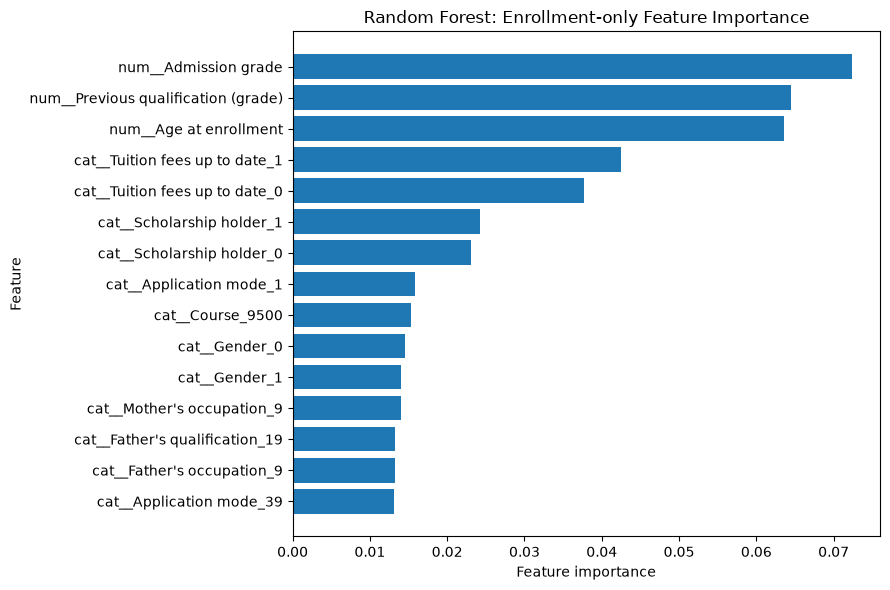

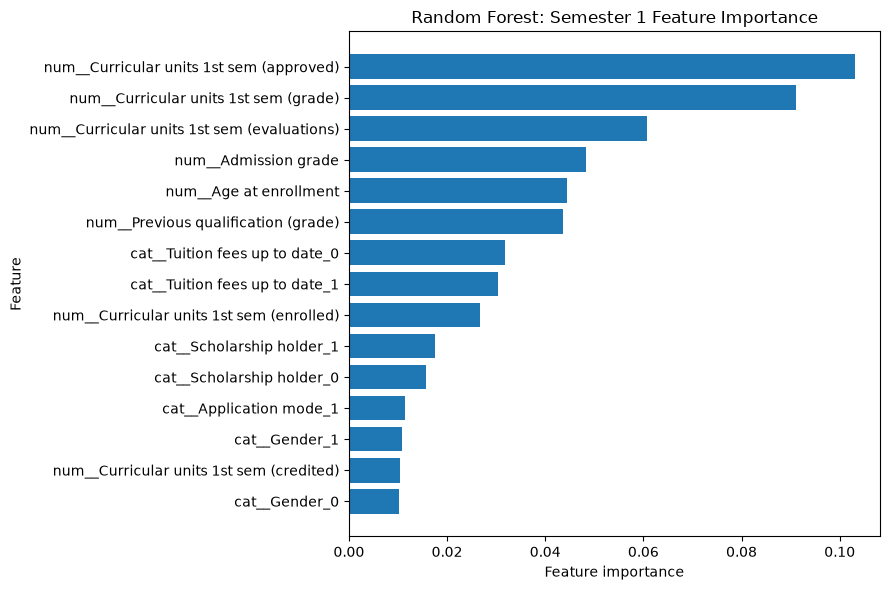

In [19]:
def plot_importance(importance_df, title, top_n=15):
    plot_df = importance_df.head(top_n).sort_values(
        "Importance",
        ascending=True
    )

    plt.figure(figsize=(9, 6))
    plt.barh(
        plot_df["Feature"],
        plot_df["Importance"]
    )

    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_importance(
    rf_enrollment_importance,
    "Random Forest: Enrollment-only Feature Importance"
)

plot_importance(
    rf_semester1_importance,
    "Random Forest: Semester 1 Feature Importance"
)


## 20. Compare feature importance between prediction stages

The goal is to examine whether first-semester academic variables appear among the important features after they become available.



In [20]:
def identify_semester1_features(importance_df):
    return importance_df[
        importance_df["Feature"].str.contains(
            "1st sem",
            case=False,
            na=False
        )
    ]

print("Semester 1 features among top Enrollment-only features:")
display(
    identify_semester1_features(rf_enrollment_importance)
)

print("Semester 1 features among top Semester 1 features:")
display(
    identify_semester1_features(rf_semester1_importance)
)


Semester 1 features among top Enrollment-only features:


,Feature,Importance


Semester 1 features among top Semester 1 features:


,Feature,Importance
220,num__Curricular units 1st sem (approved),0.1031
221,num__Curricular units 1st sem (grade),0.0910
219,num__Curricular units 1st sem (evaluations),0.0607
218,num__Curricular units 1st sem (enrolled),0.0268
217,num__Curricular units 1st sem (credited),0.0104


## 21. Group transformed features back to original variables

One-hot encoding creates feature names such as `cat__Course_9500`.

For interpretation, it is useful to aggregate one-hot encoded features back to their original variables.

For a categorical variable, the aggregate importance is calculated by summing the importance of its encoded categories.


In [21]:
def original_feature_from_transformed(name):
    name = name.replace("cat__", "").replace("num__", "")

    for col in categorical_cols:
        prefix = f"{col}_"
        if name.startswith(prefix):
            return col

    for col in semester1_numerical_cols:
        if name == col:
            return col

    for col in numerical_cols:
        if name == col:
            return col

    return name

def aggregate_importance(importance_df):
    result = importance_df.copy()

    result["Original Feature"] = result["Feature"].apply(
        original_feature_from_transformed
    )

    grouped = (
        result
        .groupby("Original Feature", as_index=False)["Importance"]
        .sum()
        .sort_values("Importance", ascending=False)
    )

    return grouped


## 22. Aggregated Random Forest importance: Enrollment-only



In [22]:
rf_enrollment_all = pd.DataFrame({
    "Feature": get_feature_names(random_forest_enrollment),
    "Importance": random_forest_enrollment.named_steps[
        "model"
    ].feature_importances_
})

rf_enrollment_aggregated = aggregate_importance(
    rf_enrollment_all
)

display(rf_enrollment_aggregated.head(20))


,Original Feature,Importance
4,Course,0.1089
9,Father's occupation,0.0932
14,Mother's occupation,0.0803
19,Tuition fees up to date,0.0801
0,Admission grade,0.0724
2,Application mode,0.0700
10,Father's qualification,0.0695
15,Mother's qualification,0.0692
17,Previous qualification (grade),0.0645
1,Age at enrollment,0.0635


## 23. Aggregated Random Forest importance: Semester 1



In [23]:
rf_semester1_all = pd.DataFrame({
    "Feature": get_feature_names(random_forest_semester1),
    "Importance": random_forest_semester1.named_steps[
        "model"
    ].feature_importances_
})

rf_semester1_aggregated = aggregate_importance(
    rf_semester1_all
)

display(rf_semester1_aggregated.head(20))


,Original Feature,Importance
5,Curricular units 1st sem (approved),0.1031
9,Curricular units 1st sem (grade),0.0910
4,Course,0.0707
15,Father's occupation,0.0647
25,Tuition fees up to date,0.0622
8,Curricular units 1st sem (evaluations),0.0607
20,Mother's occupation,0.0562
16,Father's qualification,0.0501
2,Application mode,0.0497
21,Mother's qualification,0.0488


## 24. Visualize aggregated feature importance

Aggregating one-hot encoded categories makes the interpretation easier because the chart refers to the original dataset variables.


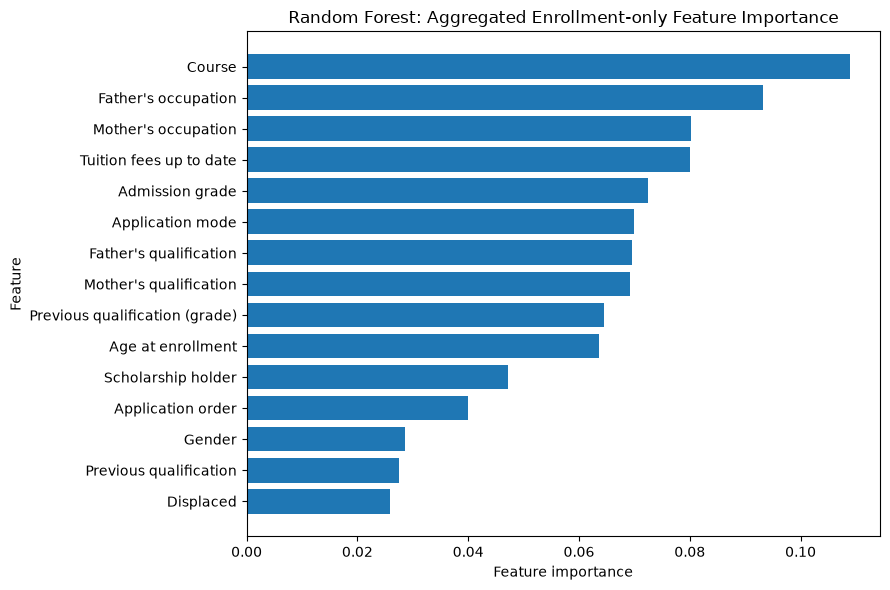

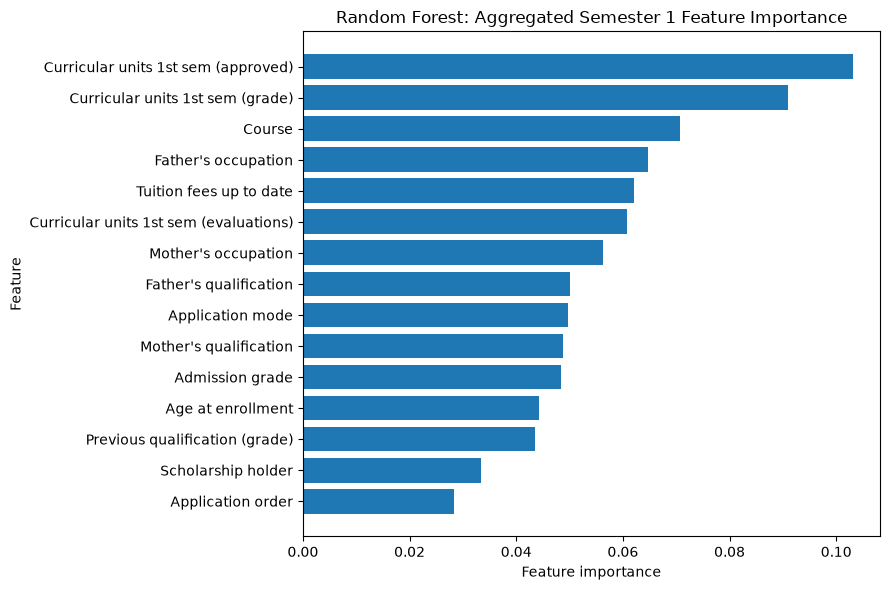

In [24]:
plot_importance(
    rf_enrollment_aggregated.rename(
        columns={"Original Feature": "Feature"}
    ),
    "Random Forest: Aggregated Enrollment-only Feature Importance"
)

plot_importance(
    rf_semester1_aggregated.rename(
        columns={"Original Feature": "Feature"}
    ),
    "Random Forest: Aggregated Semester 1 Feature Importance"
)


## 25. Interpretation notes

The feature importance results should be interpreted carefully.

- A feature can be important for prediction without causing the outcome.
- One-hot encoded categories represent specific values of categorical variables.
- Aggregated importance combines the contributions of those encoded categories.
- Different algorithms can identify different important features.
- Importance does not indicate the direction of the relationship for tree-based models.
- Logistic Regression coefficients provide direction for each class, but their interpretation is conditional on the other variables in the model.


## 26. Findings

Complete this section after reviewing the executed outputs.

### Finding 1: Enrollment-stage predictors

Identify the variables that appear most important before first-semester academic information is available.

### Finding 2: Semester 1 predictors

Identify which variables become important after first-semester information is added.

### Finding 3: Contribution of academic variables

Describe whether first-semester academic variables appear prominently in the Semester 1 model.

### Finding 4: Agreement between models

Describe any features that appear important across Logistic Regression, Decision Tree, and Random Forest.

### Finding 5: Interpretation limitations

State that model importance represents predictive association within the fitted model and does not establish causation.


## 27. Next step

The next notebook will consolidate the project into a final model evaluation and portfolio-ready summary.

The final analysis should preserve the distinction between information available at enrollment and information available after Semester 1.
